In [8]:
# ライブラリのインポート
import cshogi.KIF as KIF
import pandas as pd
import numpy as np
import os
import re
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 日本語フォント設定（Mac）
matplotlib.rcParams['font.family'] = 'Hiragino Sans'

In [9]:
def normalize_name(name):
    """
    棋士名の正規化
    - 全角・半角スペース、中点を除去
    - 段位・タイトルを除去
    例）'藤井　聡太 名人' → '藤井聡太'
    """
    name = re.sub(r'[\u3000\s・]', '', name)
    name = re.sub(r'(九段|八段|七段|六段|五段|四段|三段|二段|初段|名人|竜王|王位|王座|棋王|王将|棋聖|叡王|二冠|三冠|四冠|五冠|六冠|七冠)', '', name)
    return name

def classify_style(sentype):
    """
    戦型を居飛車・振り飛車に分類
    KIFファイルのvar_info['戦型']を入力とする
    """
    if sentype is None:
        return 'unknown'
    furibisha = ['四間飛車', '三間飛車', '中飛車', '向かい飛車', '振り飛車', '石田流', '角交換振り飛車']
    for f in furibisha:
        if f in sentype:
            return '振り飛車'
    return '居飛車'

In [10]:
# data/配下の棋士フォルダからKIFファイルを再帰的に読み込む
# フォルダ構成: data/{棋士名}/{棋譜ファイル}.kif
data_dir = "../data/"
records = []

for player_dir in os.listdir(data_dir):
    player_path = os.path.join(data_dir, player_dir)
    if not os.path.isdir(player_path):
        continue

    for filename in os.listdir(player_path):
        if not filename.endswith(".kif"):
            continue

        filepath = os.path.join(player_path, filename)

        # 文字コードがcp932・utf-8の両方に対応
        try:
            kifu = KIF.Parser.parse_file(filepath)
        except UnicodeDecodeError:
            try:
                with open(filepath, encoding="utf-8") as f:
                    content = f.read()
                kifu = [KIF.Parser.parse_str(content)]
            except Exception as e:
                print(f"スキップ: {filename}, エラー: {e}")
                continue

        for k in kifu:
            moves_count = len(k.moves)
            if moves_count == 0:
                continue

            # 投了した側から勝者を判定
            # 奇数手：先手が最後に指した→後手が投了→先手の勝ち
            # 偶数手：後手が最後に指した→先手が投了→後手の勝ち
            winner = normalize_name(k.names[0]) if moves_count % 2 == 1 else normalize_name(k.names[1])

            records.append({
                '棋士フォルダ': player_dir,
                '先手': normalize_name(k.names[0]),
                '後手': normalize_name(k.names[1]),
                '勝者': winner,
                '手数': moves_count,
                '戦型': classify_style(k.var_info.get('戦型', None)),
            })

df = pd.DataFrame(records)
print(f"総棋譜数: {len(df)}")
print(df.head())

総棋譜数: 250
  棋士フォルダ                 先手     後手                 勝者   手数   戦型
0   羽生善治               羽生善治  斎藤明日斗               羽生善治  123  居飛車
1   羽生善治  SUNTORY将棋オールスター東西   羽生善治  SUNTORY将棋オールスター東西  135  居飛車
2   羽生善治                本田奎   羽生善治               羽生善治   88  居飛車
3   羽生善治               羽生善治   木村一基               羽生善治  147  居飛車
4   羽生善治              佐々木大地   羽生善治               羽生善治  104  居飛車


In [11]:
# 分析対象の棋士
target_players = ['羽生善治', '伊藤匠', '藤井聡太', '菅井竜也', '渡辺明']
records_player = []

for player in target_players:
    player_df = df[df['棋士フォルダ'] == player]
    total = len(player_df)

    # 勝敗集計
    wins = (player_df['勝者'] == player).sum()

    # 先手・後手別集計
    sente_df = player_df[player_df['先手'] == player]
    gote_df = player_df[player_df['後手'] == player]
    sente_wins = (sente_df['勝者'] == player).sum()
    gote_wins = (gote_df['勝者'] == player).sum()

    # 勝利時・敗北時の棋譜
    win_df = player_df[player_df['勝者'] == player]
    lose_df = player_df[player_df['勝者'] != player]

    records_player.append({
        '棋士': player,
        '勝率': round(wins / total, 3),
        '平均手数': round(player_df['手数'].mean(), 1),
        '先手勝率': round(sente_wins / len(sente_df), 3) if len(sente_df) > 0 else 0,
        '後手勝率': round(gote_wins / len(gote_df), 3) if len(gote_df) > 0 else 0,
        '短期決戦率': round((player_df['手数'] < 100).sum() / total, 3),  # 100手未満
        '長期戦率': round((player_df['手数'] > 130).sum() / total, 3),    # 130手超
        '勝利時平均手数': round(win_df['手数'].mean(), 1),
        '敗北時平均手数': round(lose_df['手数'].mean(), 1),
        '振り飛車率': round((player_df['戦型'] == '振り飛車').sum() / total, 3),
    })

summary_df = pd.DataFrame(records_player)
print(summary_df)

     棋士    勝率   平均手数   先手勝率   後手勝率  短期決戦率  長期戦率  勝利時平均手数  敗北時平均手数  振り飛車率
0  羽生善治  0.64  109.9  0.630  0.652   0.42  0.20    111.5    107.0   0.16
1   伊藤匠  0.74  108.4  0.720  0.760   0.38  0.12    109.2    105.8   0.18
2  藤井聡太  0.74  109.3  0.792  0.720   0.42  0.24    106.9    115.9   0.14
3  菅井竜也  0.48  120.2  0.583  0.385   0.26  0.30    128.0    113.0   0.90
4   渡辺明  0.44  108.8  0.375  0.520   0.44  0.20    105.5    111.4   0.08


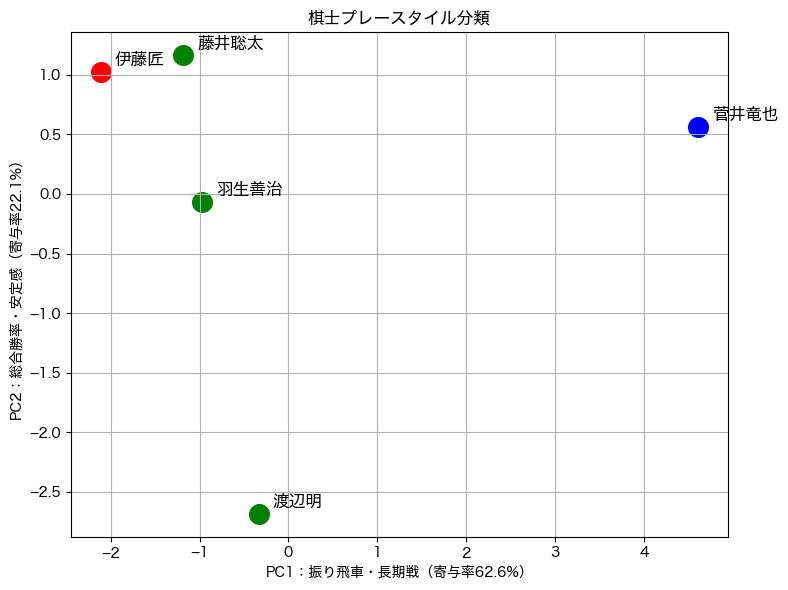

     棋士  クラスタ
0  羽生善治     2
1   伊藤匠     0
2  藤井聡太     2
3  菅井竜也     1
4   渡辺明     2


In [12]:
# 使用する特徴量
features = ['勝率', '平均手数', '先手勝率', '後手勝率', '短期決戦率', '長期戦率',
            '勝利時平均手数', '敗北時平均手数', '振り飛車率']
X = summary_df[features].values

# 標準化（特徴量のスケールを揃える）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# k-meansクラスタリング（3クラスタ）
kmeans = KMeans(n_clusters=3, random_state=42)
summary_df['クラスタ'] = kmeans.fit_predict(X_scaled)

# PCAで2次元に圧縮して可視化
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 散布図の描画
colors = ['red', 'blue', 'green']
plt.figure(figsize=(8, 6))
for i, row in summary_df.iterrows():
    plt.scatter(X_pca[i, 0], X_pca[i, 1],
                color=colors[row['クラスタ']], s=200)
    plt.annotate(row['棋士'], (X_pca[i, 0], X_pca[i, 1]),
                textcoords="offset points", xytext=(10, 5), fontsize=12)

plt.title('棋士プレースタイル分類')
plt.xlabel(f'PC1：振り飛車・長期戦（寄与率{pca.explained_variance_ratio_[0]:.1%}）')
plt.ylabel(f'PC2：総合勝率・安定感（寄与率{pca.explained_variance_ratio_[1]:.1%}）')
plt.grid(True)
plt.tight_layout()
plt.show()

print(summary_df[['棋士', 'クラスタ']])